In [1]:
##### Overlays capital and labor with priority maps: calculations and figures

import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import matplotlib.transforms as transforms
from matplotlib.lines import Line2D
import rasterio.features
from matplotlib import gridspec
import rioxarray as rio

In [2]:
##### Load data

# Get the current working directory
cd = Path.cwd().parent 

# capital rasters
capital = f"{cd}/Results/Raster_model/reprojected/rescaled_capital_USD.tif"
capital_p10 = f"{cd}/Results/Raster_model/reprojected/rescaled_capital_USD_p10.tif"
capital_p90 = f"{cd}/Results/Raster_model/reprojected/rescaled_capital_USD_p90.tif"
capital_country_avg = f"{cd}/Results/Raster_model/reprojected/rescaled_capital_USD_country_avg.tif"

# labor rasters
labor = f"{cd}/Results/Raster_model/reprojected/rescaled_jobs.tif"
labor_p10 = f"{cd}/Results/Raster_model/reprojected/rescaled_jobs_p10.tif"
labor_p90 = f"{cd}/Results/Raster_model/reprojected/rescaled_jobs_p90.tif"
labor_country_avg = f"{cd}/Results/Raster_model/reprojected/rescaled_jobs_country_avg.tif"

# priority rasters
# 0 = no in top 30%, 1 = in top 30%, not PA, 2 = in top 30%, already PA

biodiversity_no_PA = f"{cd}/Data/Clean/Priority_areas/biodiversity_no_PA.tif"
biodiversity_with_PA = f"{cd}/Data/Clean/Priority_areas/biodiversity_with_PA.tif"

all_no_PA = f"{cd}/Data/Clean/Priority_areas/all_no_PA.tif"
all_with_PA = f"{cd}/Data/Clean/Priority_areas/all_with_PA.tif"

# country boundaries 
country_shp = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')
country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

# Import country data
national_capital = pd.read_csv(f"{cd}/Results/Raster_model/intermediate_outputs/national_scaling_factors_capital.csv")
national_labor = pd.read_csv(f"{cd}/Results/Raster_model/intermediate_outputs/national_scaling_factors_labor.csv")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/priority_areas"

#### Global summary

In [6]:
##### Create summary table 

# function to read raster 
def read_array(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            arr = np.where(arr == nodata, np.nan, arr)
    return arr

# function to mask raster
def masked_sum(value_arr, priority_arr, class_vals):
    mask = np.isin(priority_arr, class_vals)
    return np.nansum(value_arr[mask])

# dictionary of raster scenarios
priority_rasters = {
    "Biodiversity - No PA":   {"path": biodiversity_no_PA,   "has_pa_split": True},
    "Biodiversity - With PA": {"path": biodiversity_with_PA, "has_pa_split": True},
    "All - No PA":            {"path": all_no_PA,            "has_pa_split": True},
    "All - With PA":          {"path": all_with_PA,          "has_pa_split": True},
}

value_rasters = {
    "Capital": {"base": capital, "p10": capital_p10, "p90": capital_p90, "country_avg": capital_country_avg},
    "Labor":   {"base": labor,   "p10": labor_p10,   "p90": labor_p90,   "country_avg": labor_country_avg},
}

### build summary table
rows = []

for var_name, paths in value_rasters.items():
    base_arr = read_array(paths["base"])
    p10_arr = read_array(paths["p10"])
    p90_arr = read_array(paths["p90"])
    country_avg_arr = read_array(paths["country_avg"])
    global_total = np.nansum(base_arr)
    global_total_country_avg = np.nansum(country_avg_arr)

    for scenario_name, info in priority_rasters.items():
        pr_arr = read_array(info["path"])

        if info["has_pa_split"]:
            classes = {"Not PA (1)": [1], "Already PA (2)": [2], "Total top 30%": [1, 2]}
        else:
            classes = {"Total top 30%": [1]}

        for class_label, class_vals in classes.items():
            base_sum = masked_sum(base_arr, pr_arr, class_vals)
            p10_sum = masked_sum(p10_arr, pr_arr, class_vals)
            p90_sum = masked_sum(p90_arr, pr_arr, class_vals)
            country_avg_sum = masked_sum(country_avg_arr, pr_arr, class_vals)

            rows.append({
                "Variable": var_name,
                "Scenario": scenario_name,
                "Class": class_label,
                "Sum": base_sum,
                "Sum_p10": p10_sum,
                "Sum_p90": p90_sum,
                "Sum_country_avg": country_avg_sum,
                "Pct_of_global": 100 * base_sum / global_total,
                "Pct_of_global_p10": 100 * p10_sum / global_total,
                "Pct_of_global_p90": 100 * p90_sum / global_total,
                "Pct_of_global_country_avg": 100 * country_avg_sum / global_total_country_avg,
            })

summary_df = pd.DataFrame(rows)


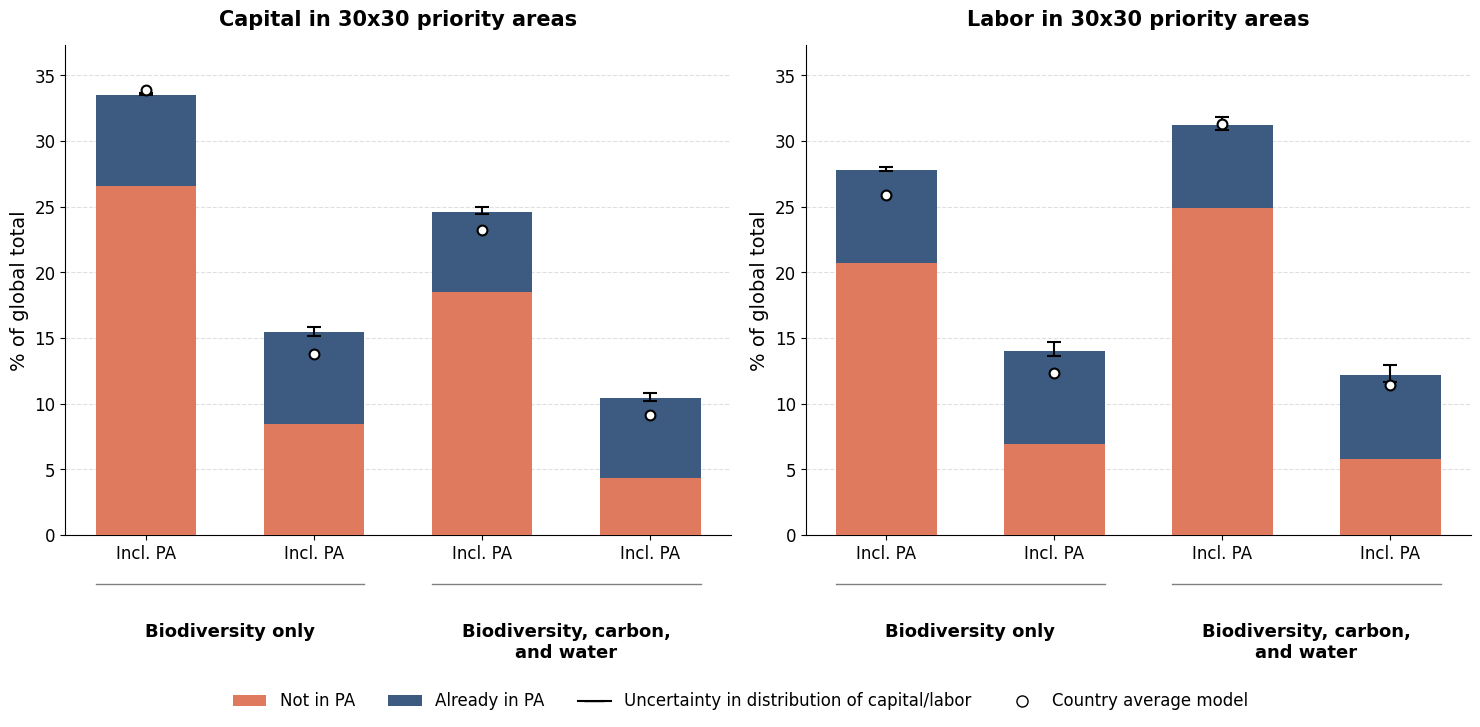

In [7]:
##### Bar chart showing % of capital and labor in priority area under each scenario

plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

color_top30 = "#E07A5F"       # terracotta — not in PA
color_already_pa = "#3D5A80"  # slate blue — already in PA

def get_max_extent(summary_df, variable_name):
    """Find the tallest bar-top + upper error bar (or country-avg dot) for a given variable, for shared y-axis scaling."""
    sub = summary_df[summary_df["Variable"] == variable_name]
    max_val = 0
    for scenario in priority_rasters.keys():
        scen_data = sub[sub["Scenario"] == scenario]
        total_row = scen_data[scen_data["Class"] == "Total top 30%"]
        total_pct = total_row["Pct_of_global"].values[0]
        p90_pct = total_row["Pct_of_global_p90"].values[0]
        p10_pct = total_row["Pct_of_global_p10"].values[0]
        country_avg_pct = total_row["Pct_of_global_country_avg"].values[0]
        top = max(total_pct, p90_pct, p10_pct, country_avg_pct)
        max_val = max(max_val, top)
    return max_val

def plot_priority_bar(summary_df, variable_name, ax, shared_ymax):
    sub = summary_df[summary_df["Variable"] == variable_name]
    scenarios = list(priority_rasters.keys())
    x = np.arange(len(scenarios))
    width = 0.6

    for i, scenario in enumerate(scenarios):
        scen_data = sub[sub["Scenario"] == scenario]
        has_split = priority_rasters[scenario]["has_pa_split"]

        if has_split:
            not_pa = scen_data.loc[scen_data["Class"] == "Not PA (1)", "Pct_of_global"].values[0]
            already_pa = scen_data.loc[scen_data["Class"] == "Already PA (2)", "Pct_of_global"].values[0]
            ax.bar(i, not_pa, width, color=color_top30, zorder=3)
            ax.bar(i, already_pa, width, bottom=not_pa, color=color_already_pa, zorder=3)
            total_pct = not_pa + already_pa
        else:
            total_pct = scen_data.loc[scen_data["Class"] == "Total top 30%", "Pct_of_global"].values[0]
            ax.bar(i, total_pct, width, color=color_top30, zorder=3)

        total_row = scen_data[scen_data["Class"] == "Total top 30%"]
        p10_pct = total_row["Pct_of_global_p10"].values[0]
        p90_pct = total_row["Pct_of_global_p90"].values[0]
        lower = max(total_pct - min(p10_pct, p90_pct), 0)
        upper = max(max(p10_pct, p90_pct) - total_pct, 0)
        ax.errorbar(i, total_pct, yerr=[[lower], [upper]], fmt="none", color="black",
                     capsize=5, capthick=1.5, linewidth=1.5, zorder=4)

        country_avg_pct = total_row["Pct_of_global_country_avg"].values[0]
        ax.scatter(i, country_avg_pct, marker="o", s=50, facecolor="white",
                    edgecolor="black", linewidth=1.5, zorder=5)

    short_labels = ["Excl. PA" if not priority_rasters[s]["has_pa_split"] else "Incl. PA" for s in scenarios]
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels)

    group_defs = [(0, 1, "Biodiversity only"), (2, 3, "Biodiversity, carbon,\nand water")]
    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    for i0, i1, label in group_defs:
        center = (i0 + i1) / 2
        ax.text(center, -0.18, label, transform=trans, ha="center", va="top", fontsize=13, fontweight="bold")
        ax.plot([i0 - width/2, i1 + width/2], [-0.10, -0.10], transform=trans,
                 color="grey", linewidth=1, clip_on=False)

    ax.set_ylabel("% of global total")
    ax.set_ylim(0, shared_ymax)
    ax.set_title(f"{variable_name} in 30x30 priority areas", pad=14, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)


# shared y-axis max across both variables, with a little headroom
shared_ymax = max(get_max_extent(summary_df, "Capital"), get_max_extent(summary_df, "Labor")) * 1.1

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
plot_priority_bar(summary_df, "Capital", axes[0], shared_ymax)
plot_priority_bar(summary_df, "Labor", axes[1], shared_ymax)

legend_elements = [
    Patch(facecolor=color_top30, label="Not in PA"),
    Patch(facecolor=color_already_pa, label="Already in PA"),
    Line2D([0], [0], color="black", marker="_", markersize=15, linewidth=1.5,
           label="Uncertainty in distribution of capital/labor"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="white", markeredgecolor="black",
           markersize=8, linewidth=1.5, label="Country average model"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.tight_layout()
plt.savefig(f"{fd}/global_summary_bar.png", dpi=200, bbox_inches="tight")
plt.show()


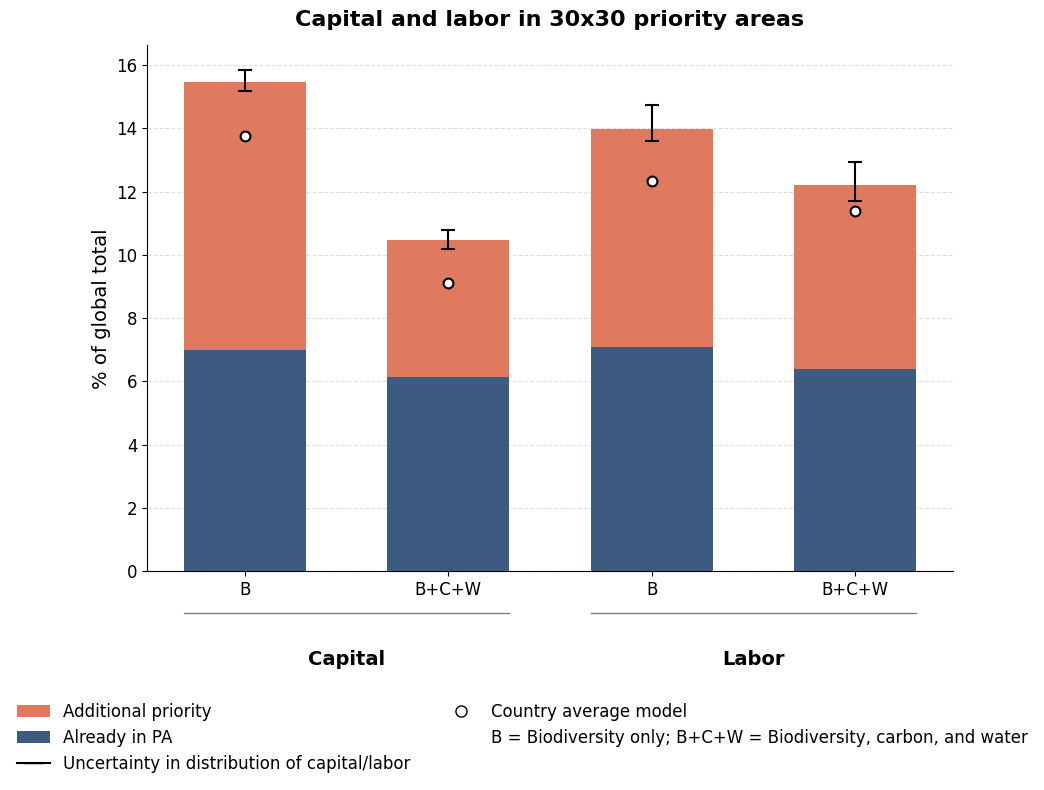

In [15]:
##### Single combined chart: % of capital and labor in top 30% priority areas (With PA only)

import matplotlib.transforms as transforms
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

color_top30 = "#E07A5F"       # terracotta — not in PA
color_already_pa = "#3D5A80"  # slate blue — already in PA

# Only these two (with-PA) scenarios are used, for both variables
scenario_order = ["Biodiversity - With PA", "All - With PA"]
scenario_short = {"Biodiversity - With PA": "B", "All - With PA": "B+C+W"}

# Build the 4 bars in order: Capital-B, Capital-BCW, Labor-B, Labor-BCW
bar_defs = [("Capital", s) for s in scenario_order] + [("Labor", s) for s in scenario_order]
x = np.arange(len(bar_defs))
width = 0.6

fig, ax = plt.subplots(figsize=(9, 7))

for i, (variable_name, scenario) in enumerate(bar_defs):
    scen_data = summary_df[(summary_df["Variable"] == variable_name) & (summary_df["Scenario"] == scenario)]

    not_pa = scen_data.loc[scen_data["Class"] == "Not PA (1)", "Pct_of_global"].values[0]
    already_pa = scen_data.loc[scen_data["Class"] == "Already PA (2)", "Pct_of_global"].values[0]
    ax.bar(i, already_pa, width, color=color_already_pa, zorder=3)
    ax.bar(i, not_pa, width, bottom=already_pa, color=color_top30, zorder=3)
    total_pct = not_pa + already_pa

    total_row = scen_data[scen_data["Class"] == "Total top 30%"]
    p10_pct = total_row["Pct_of_global_p10"].values[0]
    p90_pct = total_row["Pct_of_global_p90"].values[0]
    lower = max(total_pct - min(p10_pct, p90_pct), 0)
    upper = max(max(p10_pct, p90_pct) - total_pct, 0)
    ax.errorbar(i, total_pct, yerr=[[lower], [upper]], fmt="none", color="black",
                 capsize=5, capthick=1.5, linewidth=1.5, zorder=4)

    country_avg_pct = total_row["Pct_of_global_country_avg"].values[0]
    ax.scatter(i, country_avg_pct, marker="o", s=50, facecolor="white",
                edgecolor="black", linewidth=1.5, zorder=5)

# per-bar labels: B / B+C+W
ax.set_xticks(x)
ax.set_xticklabels([scenario_short[s] for _, s in bar_defs])

# grouped labels spanning each pair (Capital vs Labor)
group_defs = [(0, 1, "Capital"), (2, 3, "Labor")]
trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
for i0, i1, label in group_defs:
    center = (i0 + i1) / 2
    ax.text(center, -0.15, label, transform=trans, ha="center", va="top", fontsize=14, fontweight="bold")
    ax.plot([i0 - width/2, i1 + width/2], [-0.08, -0.08], transform=trans,
             color="grey", linewidth=1, clip_on=False)

ax.set_ylabel("% of global total")
ax.set_title("Capital and labor in 30x30 priority areas", pad=14, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax.set_axisbelow(True)

legend_elements = [
    Patch(facecolor=color_top30, label="Additional priority"),
    Patch(facecolor=color_already_pa, label="Already in PA"),
    Line2D([0], [0], color="black", marker="_", markersize=15, linewidth=1.5,
           label="Uncertainty in distribution of capital/labor"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="white", markeredgecolor="black",
           markersize=8, linewidth=1.5, label="Country average model"),
    Patch(facecolor="none", edgecolor="none", label="B = Biodiversity only; B+C+W = Biodiversity, carbon, and water"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.14), frameon=False)

plt.tight_layout()
plt.savefig(f"{fd}/global_summary_bar_combined.png", dpi=200, bbox_inches="tight")
plt.show()

#### Country summary

In [6]:
##### Prep country data 

# merge 
country_shp = country_shp.merge(country_codes, left_on='GID_0', right_on='SHP_code', how='left')
national_capital = national_capital.drop(columns='Unnamed: 0')
national_labor = national_labor.drop(columns='Unnamed: 0')

country_shp = country_shp.merge(national_capital[['ISO3', 'national_total_capital_USD']], on='ISO3', how='left')
country_shp = country_shp.merge(national_labor[['ISO3', 'national_total_jobs']], on='ISO3', how='left')

In [7]:
##### Rasterize countries onto the raster grid (With-PA scenarios only)

with_pa_scenarios = {
    "Biodiversity - With PA": biodiversity_with_PA,
    "All - With PA": all_with_PA,
}

# use the capital raster as the reference grid
with rasterio.open(capital) as ref:
    ref_transform = ref.transform
    ref_shape = (ref.height, ref.width)
    ref_crs = ref.crs

# reproject country polygons to match the raster CRS if needed
country_shp_proj = country_shp.to_crs(ref_crs) if country_shp.crs != ref_crs else country_shp.copy()
country_shp_proj = country_shp_proj.reset_index(drop=True)

# integer id per country row (0..n-1); -1 = not inside any country polygon (e.g. ocean)
shapes = ((geom, i) for i, geom in enumerate(country_shp_proj.geometry) if geom is not None)
country_id_arr = rasterio.features.rasterize(
    shapes=shapes,
    out_shape=ref_shape,
    transform=ref_transform,
    fill=-1,
    dtype="int32",
)

n_countries = len(country_shp_proj)
row_to_iso3 = country_shp_proj["ISO3"].to_dict()

In [8]:
##### Zonal sum helper (value raster, masked by priority class, by country)

def zonal_sum_by_country(value_arr, priority_arr, class_vals, country_id_arr, n_countries):
    valid = (country_id_arr >= 0) & np.isin(priority_arr, class_vals) & ~np.isnan(value_arr)
    ids = country_id_arr[valid]
    vals = value_arr[valid]
    return np.bincount(ids, weights=vals, minlength=n_countries)


country_rows = []
global_totals = {}  # {"Capital": global sum USD, "Labor": global sum jobs} - for Pct_of_global
global_totals_country_avg = {}  # same, but the country-average dataset's own global total

for scenario_name, pr_path in with_pa_scenarios.items():
    pr_arr = read_array(pr_path)

    for var_name, paths in value_rasters.items():
        val_arr = read_array(paths["base"])
        val_arr_p10 = read_array(paths["p10"])
        val_arr_p90 = read_array(paths["p90"])
        val_arr_country_avg = read_array(paths["country_avg"])
        global_totals[var_name] = np.nansum(val_arr)
        global_totals_country_avg[var_name] = np.nansum(val_arr_country_avg)

        classes = {
            "Not PA (1)": [1],
            "Already PA (2)": [2],
            "Total top 30%": [1, 2],
        }

        for class_label, class_vals in classes.items():
            sums = zonal_sum_by_country(val_arr, pr_arr, class_vals, country_id_arr, n_countries)
            sums_p10 = zonal_sum_by_country(val_arr_p10, pr_arr, class_vals, country_id_arr, n_countries)
            sums_p90 = zonal_sum_by_country(val_arr_p90, pr_arr, class_vals, country_id_arr, n_countries)
            sums_country_avg = zonal_sum_by_country(val_arr_country_avg, pr_arr, class_vals, country_id_arr, n_countries)
            for row_idx in range(n_countries):
                country_rows.append({
                    "ISO3": row_to_iso3[row_idx],
                    "Scenario": scenario_name,
                    "Variable": var_name,
                    "Class": class_label,
                    "Sum": sums[row_idx],
                    "Sum_p10": sums_p10[row_idx],
                    "Sum_p90": sums_p90[row_idx],
                    "Sum_country_avg": sums_country_avg[row_idx],
                })

country_df = pd.DataFrame(country_rows)


In [9]:
##### Merge with national totals, compute % of national total, pool missing-data countries
# (now also carries Sum_p10 / Sum_p90 / Sum_country_avg through, for uncertainty bars and the
# country-average-model dot downstream)

# one national total per ISO3 (country_shp may have duplicate ISO3 rows e.g. multi-part geoms)
national_lookup = (
    country_shp_proj[["ISO3", "national_total_capital_USD", "national_total_jobs"]]
    .drop_duplicates("ISO3")
)

country_df = country_df.merge(national_lookup, on="ISO3", how="left")

national_total_col = {"Capital": "national_total_capital_USD", "Labor": "national_total_jobs"}
country_df["National_Total"] = country_df.apply(lambda r: r[national_total_col[r["Variable"]]], axis=1)
country_df = country_df.drop(columns=["national_total_capital_USD", "national_total_jobs"])

has_national = country_df["National_Total"].notna() & (country_df["National_Total"] != 0)
country_df["Pct_of_national"] = np.where(has_national, 100 * country_df["Sum"] / country_df["National_Total"], np.nan)
country_df["Pct_of_national_p10"] = np.where(has_national, 100 * country_df["Sum_p10"] / country_df["National_Total"], np.nan)
country_df["Pct_of_national_p90"] = np.where(has_national, 100 * country_df["Sum_p90"] / country_df["National_Total"], np.nan)
# country-average model uses the same national totals (redistribution within-country doesn't change the national sum)
country_df["Pct_of_national_country_avg"] = np.where(has_national, 100 * country_df["Sum_country_avg"] / country_df["National_Total"], np.nan)

# countries with no national total available at all -> pooled into "Other countries"
# (this also catches rows where ISO3 itself is missing/NaN, since those can
# never be matched to a national total anyway)
missing_iso3 = (
    country_df.loc[country_df["National_Total"].isna(), "ISO3"].unique()
)
missing_iso3 = missing_iso3[pd.notna(missing_iso3)]  # drop NaN itself out of the "known" list
missing_mask = country_df["National_Total"].isna() | country_df["ISO3"].isna()

has_data_df = country_df[~missing_mask].copy()

other_df = (
    country_df[missing_mask]
    .groupby(["Scenario", "Variable", "Class"], as_index=False)[["Sum", "Sum_p10", "Sum_p90", "Sum_country_avg"]]
    .sum()
)
other_df["ISO3"] = "OTHER"
other_df["National_Total"] = np.nan       # no national denominator for this pooled group
other_df["Pct_of_national"] = np.nan      # not meaningful to compute for a mixed block
other_df["Pct_of_national_p10"] = np.nan
other_df["Pct_of_national_p90"] = np.nan
other_df["Pct_of_national_country_avg"] = np.nan

country_summary_df = pd.concat([has_data_df, other_df], ignore_index=True, sort=False)

# % of the GLOBAL total (all countries combined) - always computable, even for "OTHER"
country_summary_df["Global_Total"] = country_summary_df["Variable"].map(global_totals)
country_summary_df["Pct_of_global"] = 100 * country_summary_df["Sum"] / country_summary_df["Global_Total"]
country_summary_df["Pct_of_global_p10"] = 100 * country_summary_df["Sum_p10"] / country_summary_df["Global_Total"]
country_summary_df["Pct_of_global_p90"] = 100 * country_summary_df["Sum_p90"] / country_summary_df["Global_Total"]

# country-average model gets its own global total (the country-avg raster's own sum)
country_summary_df["Global_Total_country_avg"] = country_summary_df["Variable"].map(global_totals_country_avg)
country_summary_df["Pct_of_global_country_avg"] = 100 * country_summary_df["Sum_country_avg"] / country_summary_df["Global_Total_country_avg"]

n_missing_rows = missing_mask.sum() // country_df["Scenario"].nunique() // country_df["Variable"].nunique() // country_df["Class"].nunique()
print(f"{len(missing_iso3)} named countries pooled into 'Other countries' (missing national total): "
      f"{sorted(str(x) for x in missing_iso3)}")
print(f"Plus any rows with a missing/NaN ISO3 (unmatched during the earlier merges), "
      f"pooled in alongside them.")


74 named countries pooled into 'Other countries' (missing national total): ['ABW', 'AIA', 'AND', 'ASM', 'ATG', 'BLM', 'BMU', 'BVT', 'CAF', 'CCK', 'COK', 'CUW', 'CXR', 'CYM', 'DMA', 'ESH', 'FLK', 'FRO', 'FSM', 'GGY', 'GIB', 'GLP', 'GRD', 'GRL', 'GUF', 'GUM', 'HMD', 'IMN', 'IOT', 'JEY', 'KIR', 'KNA', 'LIE', 'LSO', 'MAF', 'MCO', 'MDA', 'MDV', 'MHL', 'MNP', 'MSR', 'MTQ', 'MYT', 'NFK', 'NIU', 'NRU', 'OMN', 'PCN', 'PLW', 'PRK', 'QAT', 'REU', 'SDN', 'SGS', 'SJM', 'SMR', 'SSD', 'SXM', 'SYC', 'TCA', 'TKL', 'TON', 'TUV', 'TWN', 'VAT', 'VEN', 'VGB', 'VIR', 'VUT', 'WLF', 'WSM', 'XKO', 'ZNC', 'ZWE']
Plus any rows with a missing/NaN ISO3 (unmatched during the earlier merges), pooled in alongside them.


In [10]:
##### One row per country, with raw Sum, % of national, and % of global
# (by scenario & variable) - "Total top 30%" class only (Not PA + Already PA combined)

metrics = ["Sum", "Pct_of_national", "Pct_of_global"]
totals_df = country_summary_df[country_summary_df["Class"] == "Total top 30%"].copy()

pivot_df = totals_df.pivot_table(
    index="ISO3",
    columns=["Scenario", "Variable"],
    values=metrics,
    aggfunc="first",
)

# flatten the 3-level columns (metric, scenario, variable) into readable labels, e.g.
# "Biodiversity - With PA - Capital - Sum", "... - Pct_of_national", "... - Pct_of_global"
pivot_df.columns = [
    f"{scenario} - {variable} - {metric}"
    for metric, scenario, variable in pivot_df.columns
]

# order columns: Sum, Pct_of_national, Pct_of_global grouped together per scenario/variable
ordered_cols = []
for scenario in with_pa_scenarios.keys():
    for variable in value_rasters.keys():
        for metric in metrics:
            col = f"{scenario} - {variable} - {metric}"
            if col in pivot_df.columns:
                ordered_cols.append(col)
pivot_df = pivot_df[ordered_cols].round(2)

pivot_df = pivot_df.sort_values(pivot_df.columns[1], ascending=False)  # sort by first Pct_of_national col

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_43004/1730009733.py:185: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


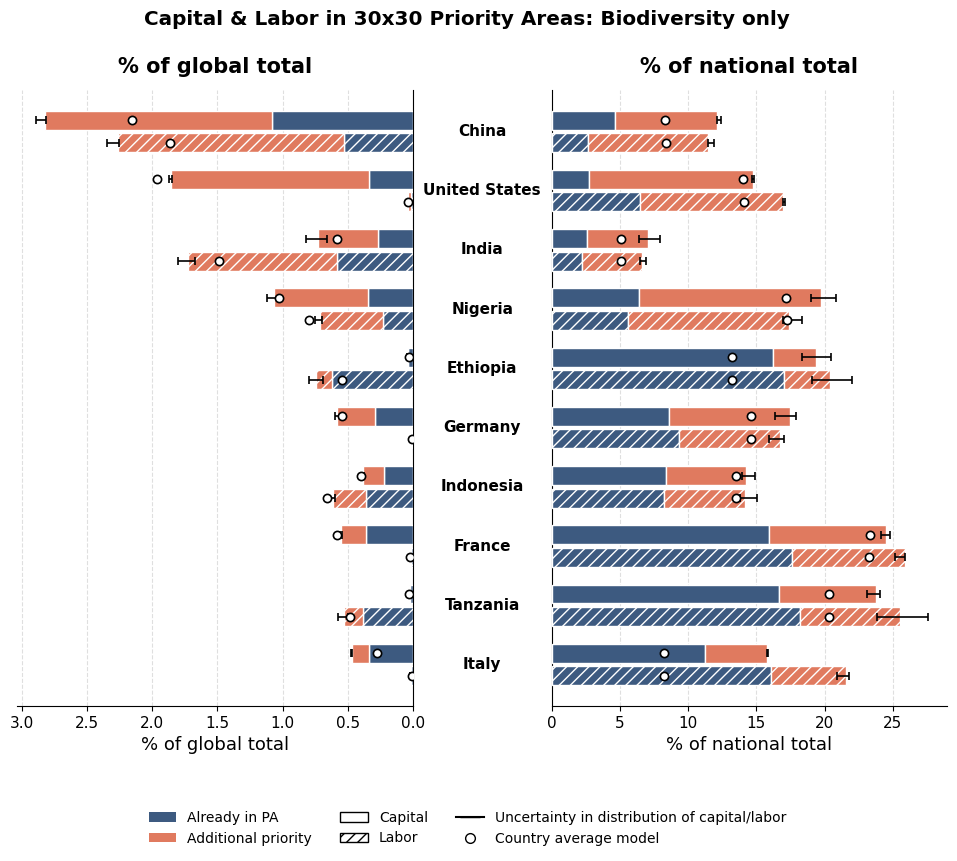

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_43004/1730009733.py:185: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


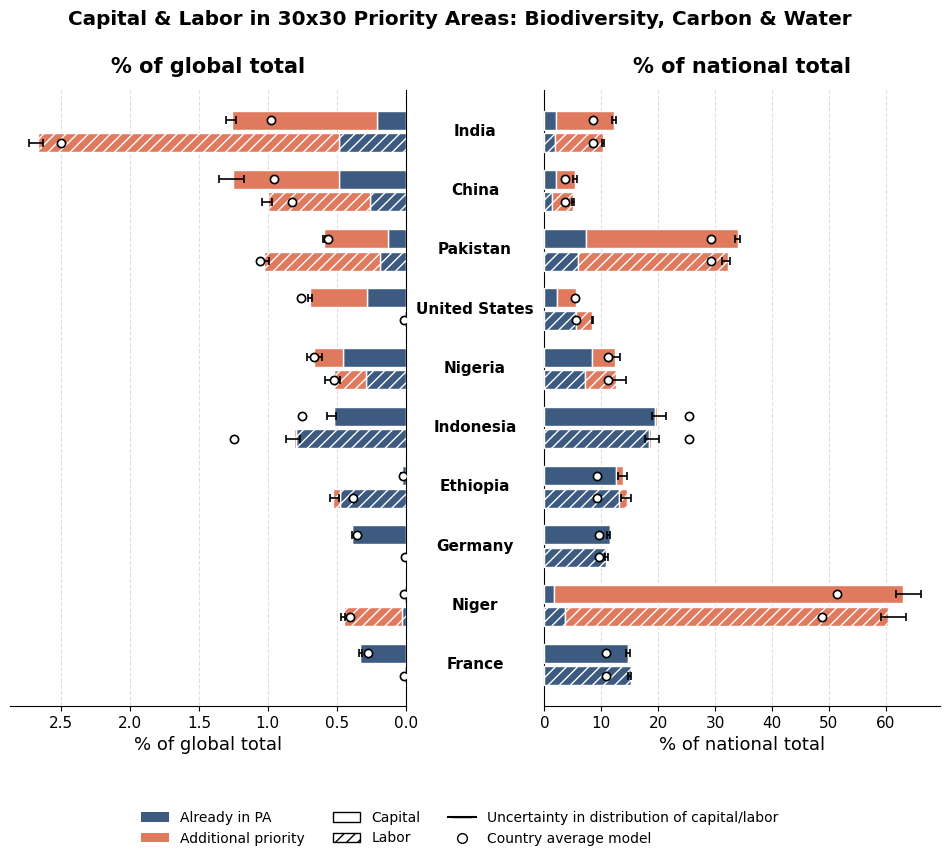

In [11]:
def plot_priority_butterfly_combined(country_summary_df, country_shp_proj, scenario,
                                       top_n=10, fd=None, filename=None):
    plt.rcParams.update({
        "font.size": 12, "axes.titlesize": 15, "axes.labelsize": 13,
        "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 10,
    })

    # -----------------------------------------------------------
    # 1. Interleaved country ranking: top1 Capital, top1 Labor, top2 Capital, ...
    # -----------------------------------------------------------
    def ranked_isos(variable):
        totals = country_summary_df[
            (country_summary_df["Scenario"] == scenario) &
            (country_summary_df["Variable"] == variable) &
            (country_summary_df["Class"] == "Total top 30%") &
            (country_summary_df["ISO3"] != "OTHER")
        ].set_index("ISO3")
        return totals["Pct_of_global"].sort_values(ascending=False).index.tolist()

    cap_rank = ranked_isos("Capital")
    lab_rank = ranked_isos("Labor")

    country_list = []
    i = 0
    while len(country_list) < top_n and i < max(len(cap_rank), len(lab_rank)):
        for rank in (cap_rank, lab_rank):
            if i < len(rank) and rank[i] not in country_list:
                country_list.append(rank[i])
            if len(country_list) == top_n:
                break
        i += 1
    n = len(country_list)

    # -----------------------------------------------------------
    # 2. Country names
    # -----------------------------------------------------------
    name_col = next((c for c in ["COUNTRY", "NAME_0", "Country", "country_name"]
                      if c in country_shp_proj.columns), None)
    if name_col:
        name_lookup = country_shp_proj[["ISO3", name_col]].drop_duplicates("ISO3").set_index("ISO3")[name_col]
    else:
        name_lookup = pd.Series({iso3: iso3 for iso3 in country_list})

    # -----------------------------------------------------------
    # 3. Helpers
    # -----------------------------------------------------------
    def get_bar_values(iso3, variable, pct_col):
        sub = country_summary_df[
            (country_summary_df["ISO3"] == iso3) &
            (country_summary_df["Variable"] == variable) &
            (country_summary_df["Scenario"] == scenario)
        ]
        already = sub.loc[sub["Class"] == "Already PA (2)", pct_col]
        total = sub.loc[sub["Class"] == "Total top 30%", pct_col]
        already = already.values[0] if len(already) else 0.0
        total = total.values[0] if len(total) else 0.0
        additional = max(total - already, 0.0)
        return already, additional

    def get_uncertainty(iso3, variable, pct_col, pct_col_p10, pct_col_p90):
        """Lower/upper error (relative to the total bar) from the p10/p90 columns,
        same logic as the global summary bar chart's error bars."""
        sub = country_summary_df[
            (country_summary_df["ISO3"] == iso3) &
            (country_summary_df["Variable"] == variable) &
            (country_summary_df["Scenario"] == scenario) &
            (country_summary_df["Class"] == "Total top 30%")
        ]
        if len(sub) == 0:
            return None
        total = sub[pct_col].values[0]
        p10 = sub[pct_col_p10].values[0]
        p90 = sub[pct_col_p90].values[0]
        if pd.isna(total) or pd.isna(p10) or pd.isna(p90):
            return None
        lower = max(total - min(p10, p90), 0)
        upper = max(max(p10, p90) - total, 0)
        return total, lower, upper

    def get_country_avg(iso3, variable, pct_col):
        """Country-average-model point estimate (dot) for the same total-top-30% bar."""
        sub = country_summary_df[
            (country_summary_df["ISO3"] == iso3) &
            (country_summary_df["Variable"] == variable) &
            (country_summary_df["Scenario"] == scenario) &
            (country_summary_df["Class"] == "Total top 30%")
        ]
        if len(sub) == 0:
            return None
        val = sub[pct_col].values[0]
        return None if pd.isna(val) else val

    # -----------------------------------------------------------
    # 4. Plot — two bars per country, offset within the row
    # -----------------------------------------------------------
    bar_h = 0.32
    offset = bar_h / 2 + 0.03

    fig = plt.figure(figsize=(12, 0.6 * n + 2))
    gs = gridspec.GridSpec(1, 3, width_ratios=[4, 1.1, 4], wspace=0.05)
    ax_left = fig.add_subplot(gs[0])
    ax_mid = fig.add_subplot(gs[1], sharey=ax_left)
    ax_right = fig.add_subplot(gs[2], sharey=ax_left)

    y_positions = np.arange(n)[::-1]

    for y, iso3 in zip(y_positions, country_list):
        for var, y_off, hatch in [("Capital", offset, None), ("Labor", -offset, "///")]:
            already_g, additional_g = get_bar_values(iso3, var, "Pct_of_global")
            already_n, additional_n = get_bar_values(iso3, var, "Pct_of_national")

            ax_left.barh(y + y_off, already_g, bar_h, color=color_already_pa,
                         edgecolor="white", hatch=hatch, zorder=3)
            ax_left.barh(y + y_off, additional_g, bar_h, left=already_g, color=color_top30,
                         edgecolor="white", hatch=hatch, zorder=3)

            ax_right.barh(y + y_off, already_n, bar_h, color=color_already_pa,
                          edgecolor="white", hatch=hatch, zorder=3)
            ax_right.barh(y + y_off, additional_n, bar_h, left=already_n, color=color_top30,
                          edgecolor="white", hatch=hatch, zorder=3)

            # uncertainty bars (p10-p90), mirroring the global bar chart
            unc_g = get_uncertainty(iso3, var, "Pct_of_global", "Pct_of_global_p10", "Pct_of_global_p90")
            if unc_g is not None:
                total_g, lower_g, upper_g = unc_g
                ax_left.errorbar(total_g, y + y_off, xerr=[[lower_g], [upper_g]], fmt="none",
                                  color="black", capsize=3, capthick=1.2, linewidth=1.2, zorder=4)

            unc_n = get_uncertainty(iso3, var, "Pct_of_national", "Pct_of_national_p10", "Pct_of_national_p90")
            if unc_n is not None:
                total_n, lower_n, upper_n = unc_n
                ax_right.errorbar(total_n, y + y_off, xerr=[[lower_n], [upper_n]], fmt="none",
                                   color="black", capsize=3, capthick=1.2, linewidth=1.2, zorder=4)

            # country-average-model dot, mirroring the global bar chart
            ca_g = get_country_avg(iso3, var, "Pct_of_global_country_avg")
            if ca_g is not None:
                ax_left.scatter(ca_g, y + y_off, marker="o", s=35, facecolor="white",
                                 edgecolor="black", linewidth=1.2, zorder=5)

            ca_n = get_country_avg(iso3, var, "Pct_of_national_country_avg")
            if ca_n is not None:
                ax_right.scatter(ca_n, y + y_off, marker="o", s=35, facecolor="white",
                                  edgecolor="black", linewidth=1.2, zorder=5)

    ax_left.set_xlabel("% of global total")
    ax_left.invert_xaxis()
    ax_left.spines[["top", "left"]].set_visible(False)
    ax_left.grid(axis="x", linestyle="--", alpha=0.4, zorder=0)
    ax_left.set_axisbelow(True)
    ax_left.set_title("% of global total", fontweight="bold", pad=12)
    ax_left.yaxis.set_visible(False)  

    ax_right.set_xlabel("% of national total")
    ax_right.spines[["top", "right"]].set_visible(False)
    ax_right.grid(axis="x", linestyle="--", alpha=0.4, zorder=0)
    ax_right.set_axisbelow(True)
    ax_right.set_title("% of national total", fontweight="bold", pad=12)
    ax_right.yaxis.set_visible(False)

    ax_mid.axis("off")
    for y, iso3 in zip(y_positions, country_list):
        label = name_lookup.get(iso3, iso3)
        ax_mid.text(0.5, y, label, ha="center", va="center", fontsize=11, fontweight="bold")
    ax_mid.set_xlim(0, 1)
    ax_left.set_ylim(-0.7, n - 0.3)

    legend_elements = [
        Patch(facecolor=color_already_pa, label="Already in PA"),
        Patch(facecolor=color_top30, label="Additional priority"),
        Patch(facecolor="white", edgecolor="black", label="Capital"),
        Patch(facecolor="white", edgecolor="black", hatch="///", label="Labor"),
        Line2D([0], [0], color="black", marker="_", markersize=15, linewidth=1.5,
               label="Uncertainty in distribution of capital/labor"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="white", markeredgecolor="black",
               markersize=7, linewidth=1.5, label="Country average model"),
    ]
    fig.legend(handles=legend_elements, loc="lower center", ncol=3,
               bbox_to_anchor=(0.5, -0.08), frameon=False)

    scenario_short = "Biodiversity only" if scenario == "Biodiversity - With PA" else "Biodiversity, Carbon & Water"
    fig.suptitle(f"Capital & Labor in 30x30 Priority Areas: {scenario_short}",
                 fontweight="bold", y=0.98)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    if fd is not None:
        fname = filename or f"country_priority_butterfly_combined_{scenario.replace(' ', '_').replace('-', '')}.png"
        plt.savefig(f"{fd}/{fname}", dpi=200, bbox_inches="tight")
    plt.show()


for scenario in ["Biodiversity - With PA", "All - With PA"]:
    plot_priority_butterfly_combined(country_summary_df, country_shp_proj, scenario, fd=fd)


#### Maps

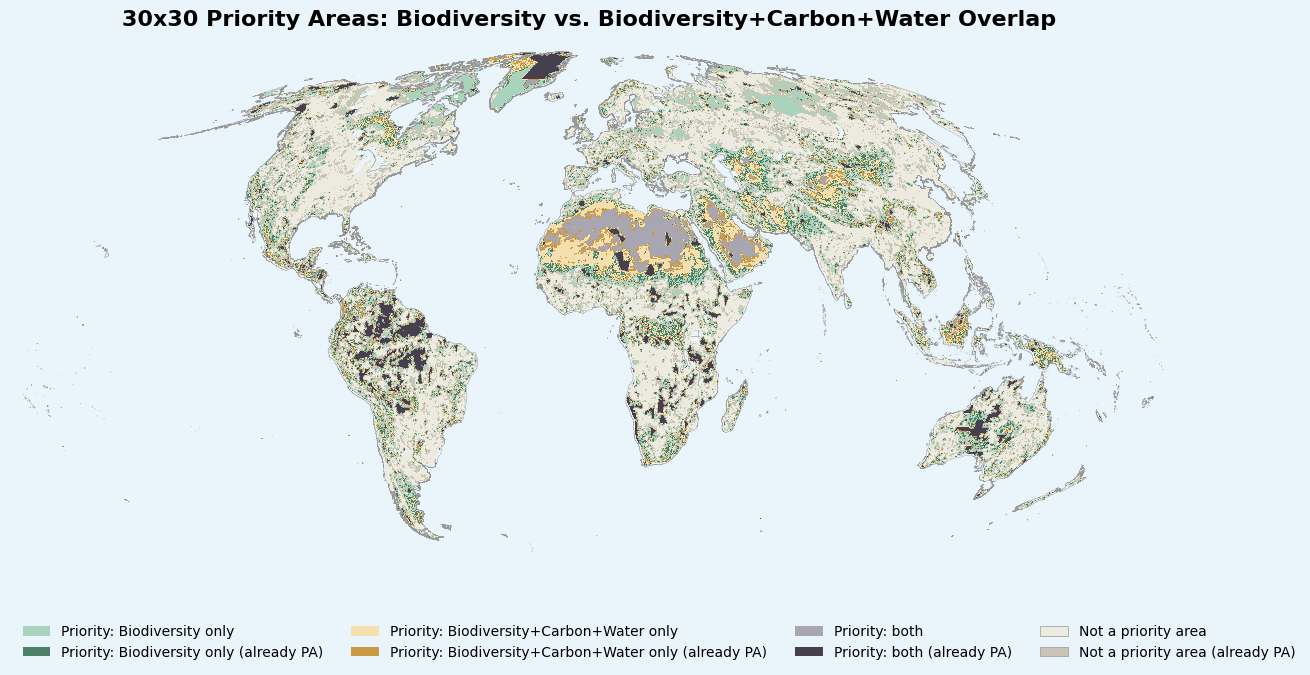

In [5]:
##### Map: classify each pixel by priority-area category AND protection status
# 0 = not priority, not PA (light)      1 = not priority, already PA (dark)
# 2 = priority: Biodiversity only, not PA (light)   3 = same, already PA (dark)
# 4 = priority: All (B+C+W) only, not PA (light)    5 = same, already PA (dark)
# 6 = priority: both, not PA (light)                7 = same, already PA (dark)
# nodata pixels (e.g. ocean) are masked out so the figure background shows through

import matplotlib.colors as mcolors
from rasterio.plot import show

# Lighter shade = not yet protected, darker shade = already a protected area
color_not_priority_light = "#EDEAE0"   # soft cream
color_not_priority_dark  = "#C9C4B4"   # deeper cream/tan

color_b_only_light = "#A8D4BE"         # light sage green
color_b_only_dark  = "#4C8168"         # deep sage green

color_all_only_light = "#F6DFAF"       # light sandy gold
color_all_only_dark  = "#C99A44"       # deep sandy gold

color_both_light = "#A9A6B3"           # light muted plum
color_both_dark  = "#453F4E"           # deep muted plum

# ---------------------------------------------------------------
# 1. Build the categorical array
# ---------------------------------------------------------------
bio_arr = read_array(biodiversity_with_PA)
all_arr = read_array(all_with_PA)

bio_top = np.isin(bio_arr, [1, 2])
all_top = np.isin(all_arr, [1, 2])
already_pa = (bio_arr == 2) | (all_arr == 2)
nodata_mask = np.isnan(bio_arr) | np.isnan(all_arr)

# Base priority category (independent of PA status)
priority_cat = np.zeros(bio_arr.shape, dtype=np.int8)
priority_cat[bio_top & ~all_top] = 1   # B only
priority_cat[~bio_top & all_top] = 2   # All only
priority_cat[bio_top & all_top] = 3    # both

# Combine priority category with PA status into final 0-7 class
# class = priority_cat * 2 + (1 if already_pa else 0)
class_arr = (priority_cat * 2 + already_pa.astype(np.int8)).astype(np.int8)
class_arr = np.where(nodata_mask, -1, class_arr)  # -1 = no data, will be masked out

masked_class_arr = np.ma.masked_where(class_arr == -1, class_arr)

cmap = mcolors.ListedColormap([
    color_not_priority_light, color_not_priority_dark,   # 0, 1
    color_b_only_light,       color_b_only_dark,         # 2, 3
    color_all_only_light,     color_all_only_dark,        # 4, 5
    color_both_light,         color_both_dark,            # 6, 7
])
bounds = [i - 0.5 for i in range(9)]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# ---------------------------------------------------------------
# 2. Plot
# ---------------------------------------------------------------
plt.rcParams.update({"font.size": 12, "legend.fontsize": 11})

with rasterio.open(biodiversity_with_PA) as src:
    raster_transform = src.transform
    raster_crs = src.crs

country_ctx = country_shp.to_crs(raster_crs) if country_shp.crs != raster_crs else country_shp

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor("#EAF4FB")   # soft ocean-blue backdrop
ax.set_facecolor("#EAF4FB")

country_ctx.boundary.plot(ax=ax, color="#999999", linewidth=0.3, zorder=1)
show(masked_class_arr, transform=raster_transform, ax=ax, cmap=cmap, norm=norm, zorder=2)

ax.set_axis_off()
ax.set_title("30x30 Priority Areas: Biodiversity vs. Biodiversity+Carbon+Water Overlap",
             fontsize=16, fontweight="bold", pad=16)

legend_elements = [
    Patch(facecolor=color_b_only_light, edgecolor="none", label="Priority: Biodiversity only"),
    Patch(facecolor=color_b_only_dark, edgecolor="none", label="Priority: Biodiversity only (already PA)"),
    Patch(facecolor=color_all_only_light, edgecolor="none", label="Priority: Biodiversity+Carbon+Water only"),
    Patch(facecolor=color_all_only_dark, edgecolor="none", label="Priority: Biodiversity+Carbon+Water only (already PA)"),
    Patch(facecolor=color_both_light, edgecolor="none", label="Priority: both"),
    Patch(facecolor=color_both_dark, edgecolor="none", label="Priority: both (already PA)"),
    Patch(facecolor=color_not_priority_light, edgecolor="#999999", linewidth=0.5, label="Not a priority area"),
    Patch(facecolor=color_not_priority_dark, edgecolor="#999999", linewidth=0.5, label="Not a priority area (already PA)"),
]
ax.legend(handles=legend_elements, loc="lower left", frameon=False, fontsize=10,
          bbox_to_anchor=(0.0, -0.10), ncol=4)

plt.tight_layout()
plt.savefig(f"{fd}/priority_overlap_map.png", dpi=250, bbox_inches="tight")
plt.show()

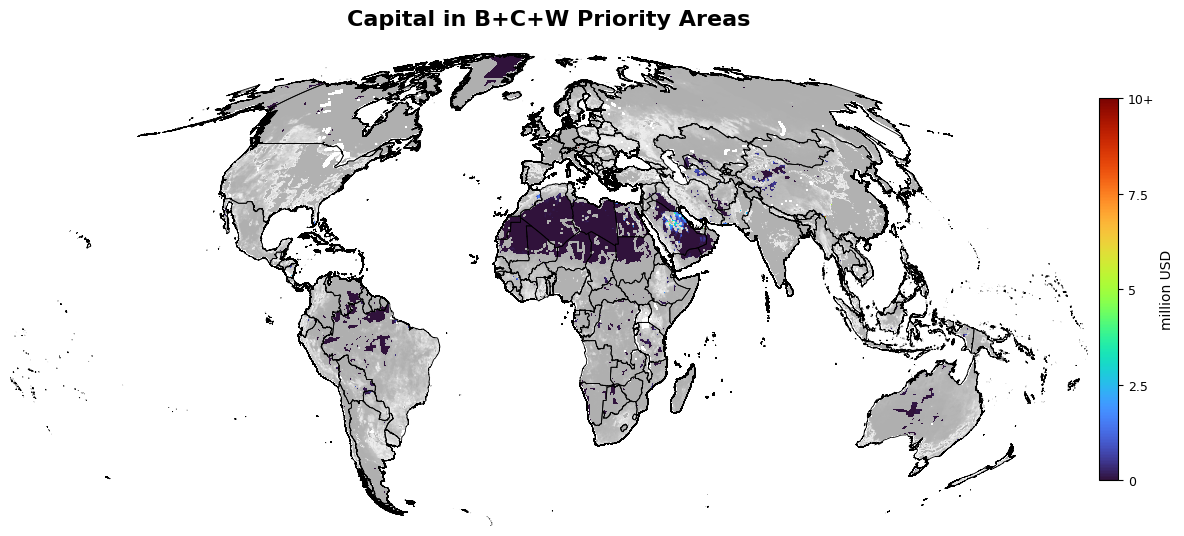

In [13]:
##### Produce map of capital in bcw priority areas — grey background (full raster, transparent) + color overlay

def desaturate_cmap(cmap, name='desaturated', lighten=0.35):
    """Convert cmap to greyscale, then lighten by blending toward white."""
    colors = cmap(np.linspace(0, 1, 256))
    luminance = colors[:, :3] @ [0.2989, 0.5870, 0.1140]
    grey_colors = np.stack([luminance, luminance, luminance, colors[:, 3]], axis=1)
    # blend toward white to soften the dark end (avoids near-black clashing with borders)
    grey_colors[:, :3] = grey_colors[:, :3] * (1 - lighten) + lighten
    return mcolors.ListedColormap(grey_colors, name=name)

import matplotlib.colors as mcolors

pr_arr = read_array(all_with_PA)
val_arr = read_array(capital)

priority_mask = np.isin(pr_arr, [1, 2])
land_mask = ~np.isnan(pr_arr)

capital_filled = np.where(np.isnan(val_arr), 0, val_arr)
capital_filled = np.where(land_mask, capital_filled, np.nan)

capital_full_million = capital_filled / 1e6
capital_priority_only = np.where(priority_mask, capital_filled, np.nan) / 1e6

name = 'capital_priority_bcw'
bounds = [0, 2.5, 5, 7.5, 10]
labels = ['0', '2.5', '5', '7.5', '10+']

with rasterio.open(all_with_PA) as src:
    raster_transform = src.transform
    raster_crs = src.crs

country_ctx = country_shp.to_crs(raster_crs) if country_shp.crs != raster_crs else country_shp

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor("white")   # so alpha blends toward white, not the notebook's default
ax.set_facecolor("white")

# Layer 1: full capital raster, greyed-out + lightened turbo, semi-transparent
grey_cmap = desaturate_cmap(plt.cm.turbo, lighten=0.35)
grey_cmap.set_bad(color="none")
masked_full = np.ma.masked_invalid(capital_full_million)
show(masked_full, transform=raster_transform, ax=ax, cmap=grey_cmap, vmin=0, vmax=10,
     alpha=0.55, zorder=1)

# Layer 2: priority-area capital, full-color turbo, on top, fully opaque
color_cmap = plt.cm.turbo.copy()
color_cmap.set_bad(color="none")
masked_priority = np.ma.masked_invalid(capital_priority_only)
show(masked_priority, transform=raster_transform, ax=ax, cmap=color_cmap, vmin=0, vmax=10, zorder=2)
im = ax.get_images()[-1]

# Country borders only
country_ctx.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=3
)

minx, miny, maxx, maxy = country_ctx.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Capital in B+C+W Priority Areas", fontsize=16, weight='bold', pad=20)

cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.02, pad=0.01, shrink=0.5)
cbar.set_label("million USD", fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')

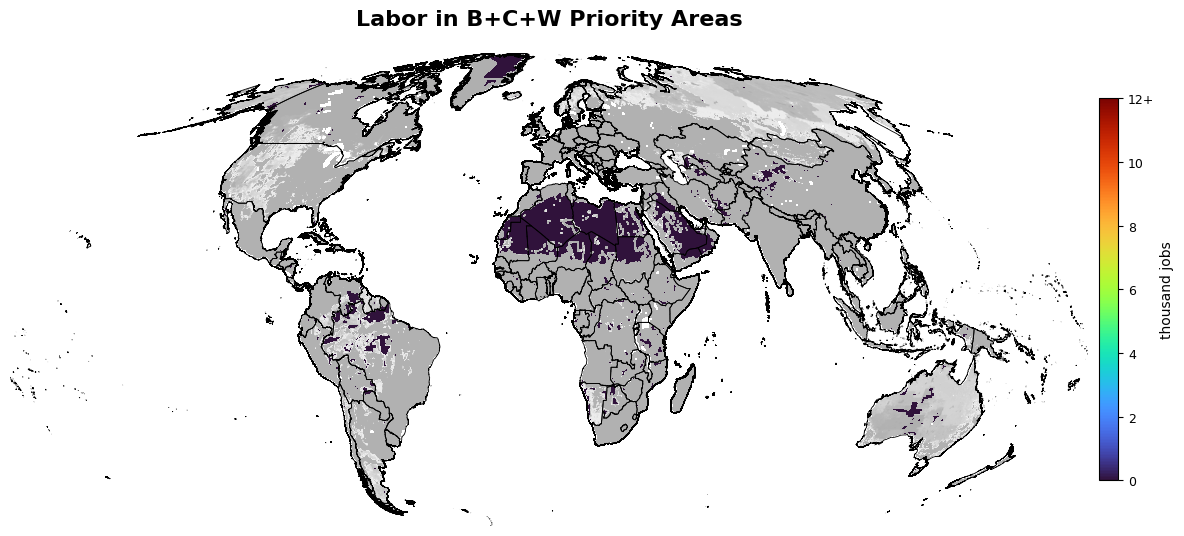

In [14]:
##### Produce map of capital in bcw priority areas — grey background (full raster, transparent) + color overlay

def desaturate_cmap(cmap, name='desaturated', lighten=0.35):
    """Convert cmap to greyscale, then lighten by blending toward white."""
    colors = cmap(np.linspace(0, 1, 256))
    luminance = colors[:, :3] @ [0.2989, 0.5870, 0.1140]
    grey_colors = np.stack([luminance, luminance, luminance, colors[:, 3]], axis=1)
    # blend toward white to soften the dark end (avoids near-black clashing with borders)
    grey_colors[:, :3] = grey_colors[:, :3] * (1 - lighten) + lighten
    return mcolors.ListedColormap(grey_colors, name=name)

import matplotlib.colors as mcolors

pr_arr = read_array(all_with_PA)
val_arr = read_array(labor)

priority_mask = np.isin(pr_arr, [1, 2])
land_mask = ~np.isnan(pr_arr)

labor_filled = np.where(np.isnan(val_arr), 0, val_arr)
labor_filled = np.where(land_mask, labor_filled, np.nan)

labor_priority_only = np.where(priority_mask, labor_filled, np.nan) / 1e6

name = 'labor_priority_bcw'
bounds = [0, 2000, 4000, 6000, 8000, 10000, 12000] 
labels = ['0', '2', '4', '6', '8', '10', '12+']

with rasterio.open(all_with_PA) as src:
    raster_transform = src.transform
    raster_crs = src.crs

country_ctx = country_shp.to_crs(raster_crs) if country_shp.crs != raster_crs else country_shp

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor("white")   # so alpha blends toward white, not the notebook's default
ax.set_facecolor("white")

# Layer 1: full capital raster, greyed-out + lightened turbo, semi-transparent
grey_cmap = desaturate_cmap(plt.cm.turbo, lighten=0.35)
grey_cmap.set_bad(color="none")
masked_full = np.ma.masked_invalid(labor_filled)
show(masked_full, transform=raster_transform, ax=ax, cmap=grey_cmap, vmin=0, vmax=10,
     alpha=0.55, zorder=1)

# Layer 2: priority-area capital, full-color turbo, on top, fully opaque
color_cmap = plt.cm.turbo.copy()
color_cmap.set_bad(color="none")
masked_priority = np.ma.masked_invalid(labor_priority_only)
show(masked_priority, transform=raster_transform, ax=ax, cmap=color_cmap, vmin=0, vmax=12000, zorder=2)
im = ax.get_images()[-1]

# Country borders only
country_ctx.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=3
)

minx, miny, maxx, maxy = country_ctx.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Labor in B+C+W Priority Areas", fontsize=16, weight='bold', pad=20)

cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.02, pad=0.01, shrink=0.5)
cbar.set_label("thousand jobs", fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')